In [1]:
import dotenv
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
try:
    train = pd.read_csv('data/train.csv')
    test = pd.read_csv('data/test.csv')
except FileNotFoundError:
    dotenv.load_dotenv(dotenv.find_dotenv())
    kagglehub.login()
    kagglehub.competition_download("playground-series-s5e1", output_dir = "./data")
    train = pd.read_csv('data/train.csv')
    test = pd.read_csv('data/test.csv')

In [3]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

In [4]:
nulls_train = train.isnull().sum() / train.shape[0]
nulls_train = nulls_train[nulls_train > 0]
print("Nulls proportion in train:")
print(nulls_train)
nulls_test = test.isnull().sum() / test.shape[0]
nulls_test = nulls_test[nulls_test > 0]
print("\nNulls proportion in test:")
print(nulls_test)

Nulls proportion in train:
num_sold    0.038548
dtype: float64

Nulls proportion in test:
Series([], dtype: float64)


Univariate Analysis

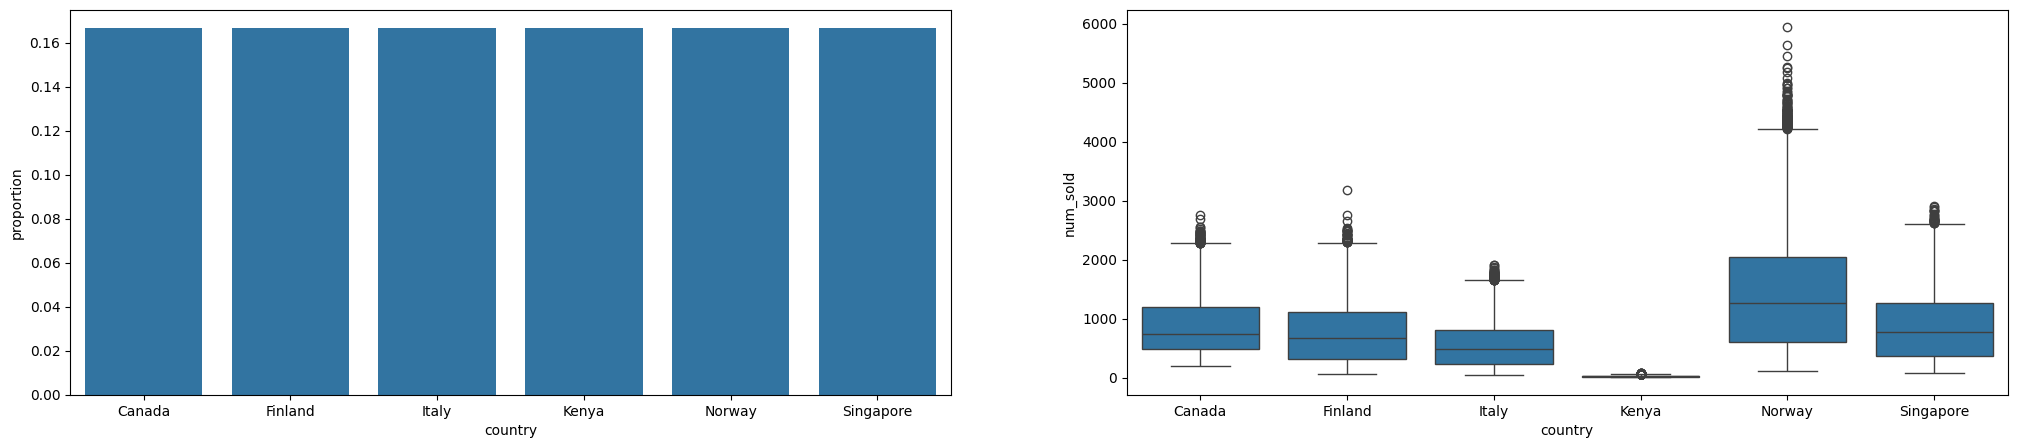

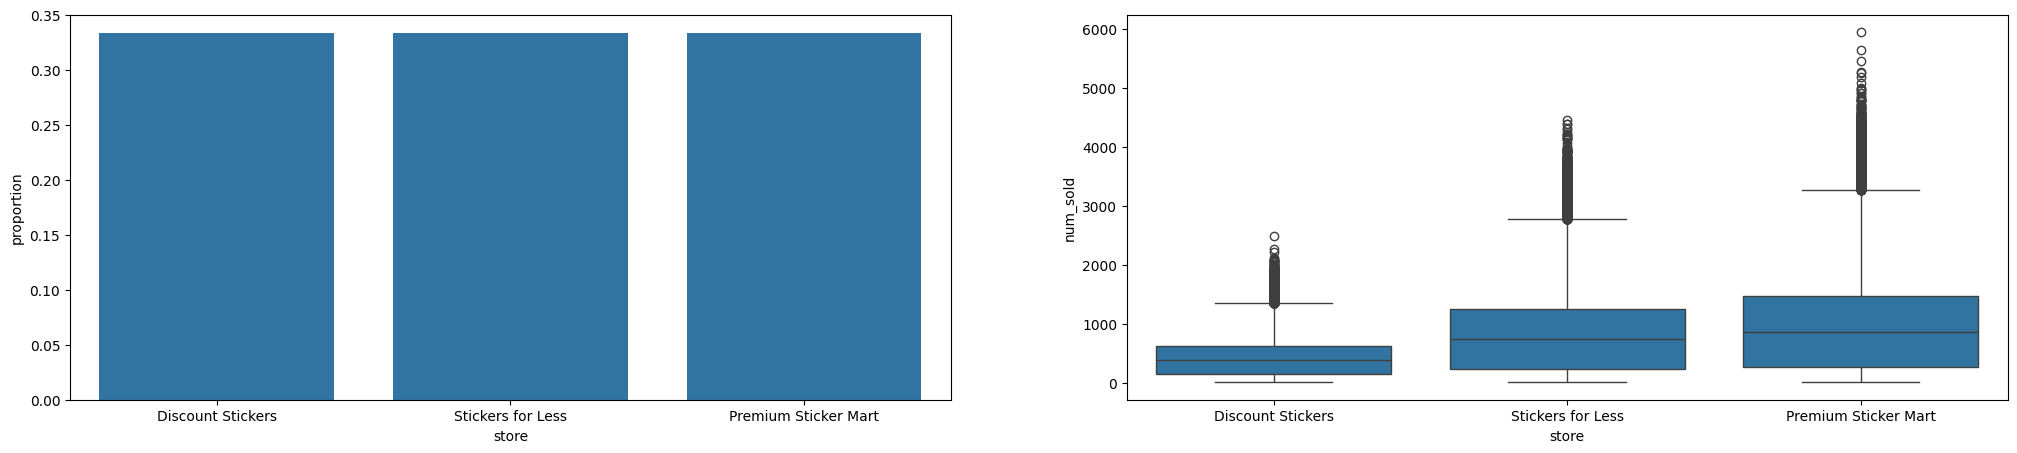

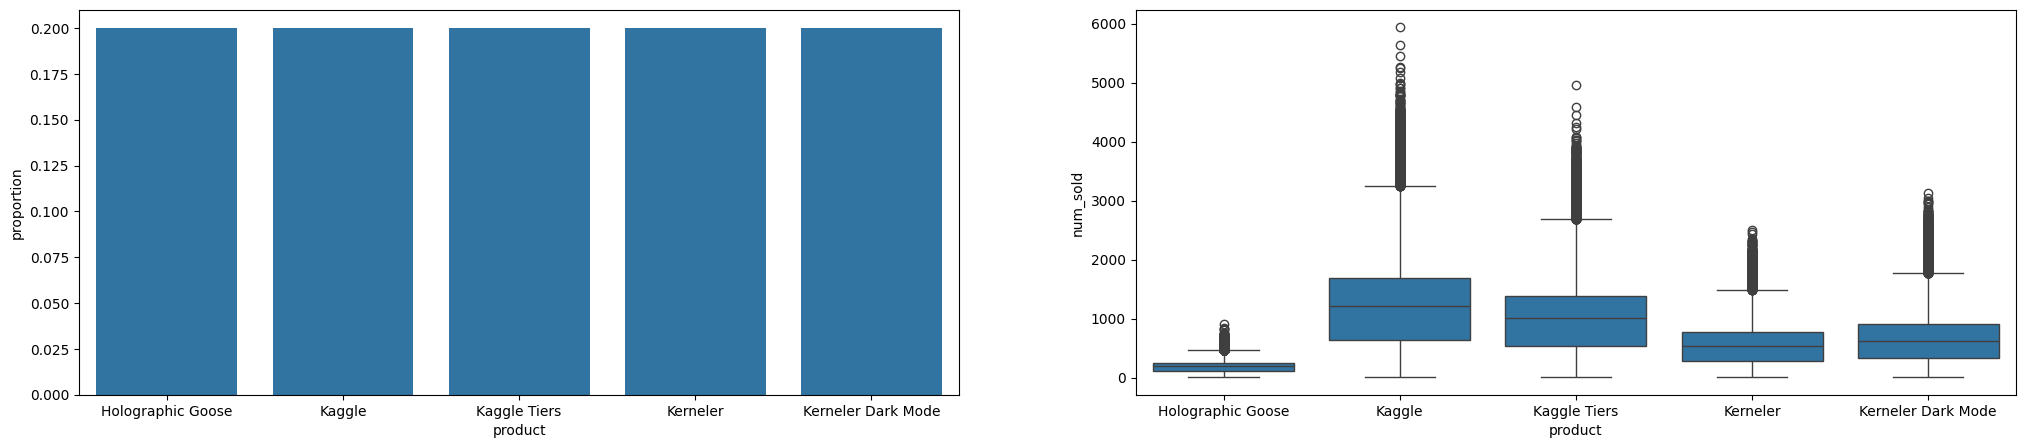

In [5]:
selected_categorical = []
for col in train.columns:
    if train[col].dtype in ["object","categorical"]:
        counts = train[col].value_counts(normalize=True).reset_index()
        plt.figure(figsize=(25,5))
        plt.subplot(1,2,1)
        sns.barplot(data=counts, x=col, y="proportion")
        plt.subplot(1,2,2)
        sns.boxplot(data=train, x=col, y="num_sold")
        plt.show()

In [6]:
def categorical_to_dummies(data: pd.DataFrame, dtype=8):
    if dtype is None:
        dtype = 64
    categorical_cols = []
    for col in data.columns:
        if data[col].dtype == "object":
            if data[col].isnull().sum() == 0:
                drop_first = True
            else:
                drop_first = False
            data = pd.concat([data, pd.get_dummies(data[col], dtype=f"int{dtype}",
                                                   drop_first=drop_first, prefix=f"{col}_")],
                            axis=1)
            categorical_cols.append(col)
    data = data.drop(columns=categorical_cols)
    return data

import numpy as np
def datetime_to_numbers(data: pd.DataFrame, date_col: str, drop_time_col=True):
    data = data.copy(deep=True)
    data["year"] = data[date_col].dt.year
    # month sin and cos restricted to range [-1, 1]
    # data["month"] = data[date_col].dt.month
    data["month_sin"] = data[date_col].dt.month.apply(np.sin)
    data["month_cos"] = data[date_col].dt.month.apply(np.cos)
    # day sin and cos restricted to range [-1, 1]
    # data["day"] = data[date_col].dt.day
    data["day_sin"] = data[date_col].dt.day.apply(np.sin)
    data["day_cos"] = data[date_col].dt.day.apply(np.cos)
    # day of week sin and cos restricted to range [-1, 1]
    # data["day_of_week"] = data[date_col].dt.dayofweek
    data["day_of_week_sin"] = data[date_col].dt.dayofweek.apply(np.sin)
    data["day_of_week_cos"] = data[date_col].dt.dayofweek.apply(np.cos)
    # day of year sin and cos restricted to range [-1, 1]
    # data["day_of_year"] = data[date_col].dt.day_of_year
    data["day_of_year_sin"] = data[date_col].dt.day_of_year.apply(np.sin)
    data["day_of_year_cos"] = data[date_col].dt.day_of_year.apply(np.cos)
    if drop_time_col:
        data = data.drop(columns=date_col)
    return data


In [7]:
train_features = train.copy(deep=True)
train_features = categorical_to_dummies(train)
# train_features = datetime_to_numbers(train_features, "date")
train_features = train_features.drop(columns=["id"])

In [8]:
test_features = test.copy(deep=True)
test_features = categorical_to_dummies(test_features)
# test_features = datetime_to_numbers(test_features, "date")
test_features = test_features[test_features.columns.intersection(train_features.columns)]

In [9]:
train_features.columns.difference(test_features.columns)

Index(['num_sold'], dtype='object')